In [29]:
!pip install nltk wordcloud seaborn

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

In [30]:
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hruda\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hruda\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [31]:
data = pd.read_csv("final_dataset.csv")

print("Initial Shape:", data.shape)
data.head()

Initial Shape: (13389, 2)


,resume_text,category
0,﻿________________\r\n\r\nEDUCATION\r\nOMBA - E...,Accountant
1,﻿________________\r\n\r\nHOWARD GERRARD\r\nAcc...,Accountant
2,﻿________________\r\n\r\nKevin Frank\r\nSENIOR...,Accountant
3,﻿________________\r\n\r\nPlace of birth\r\nNat...,Accountant
4,"﻿________________\r\n\r\nStephen Greet, CPA\r\...",Accountant


In [32]:
print("\nMissing Values:\n", data.isnull().sum())


Missing Values:
 resume_text    0
category       0
dtype: int64


In [33]:
print("\nDuplicate Rows:", data.duplicated().sum())


Duplicate Rows: 1024


In [34]:
data = data.drop_duplicates().reset_index(drop=True)

In [35]:
print("\nFinal Shape after cleaning:", data.shape)


Final Shape after cleaning: (12365, 2)


In [36]:
data.head()

,resume_text,category
0,﻿________________\r\n\r\nEDUCATION\r\nOMBA - E...,Accountant
1,﻿________________\r\n\r\nHOWARD GERRARD\r\nAcc...,Accountant
2,﻿________________\r\n\r\nKevin Frank\r\nSENIOR...,Accountant
3,﻿________________\r\n\r\nPlace of birth\r\nNat...,Accountant
4,"﻿________________\r\n\r\nStephen Greet, CPA\r\...",Accountant


In [37]:
print("\nNumber of Categories:", data['category'].nunique())


Number of Categories: 43


In [38]:
print("\nCategory Distribution:\n")
print(data['category'].value_counts())


Category Distribution:

category
Education                    389
Electrical Engineering       365
Sales                        348
Consultant                   346
Mechanical Engineer          342
Digital Media                342
Accountant                   337
Operations Manager           336
Building and Construction    336
Finance                      333
Aviation                     328
Testing                      323
Management                   322
Apparel                      317
Business Analyst             314
Public Relations             314
Civil Engineer               311
Network Security Engineer    311
Architecture                 307
Java Developer               306
Automobile                   305
Human Resources              305
SQL Developer                301
DotNet Developer             300
Health and Fitness           297
Web Designing                297
Banking                      293
SAP Developer                285
Advocate                     284
Data Scie

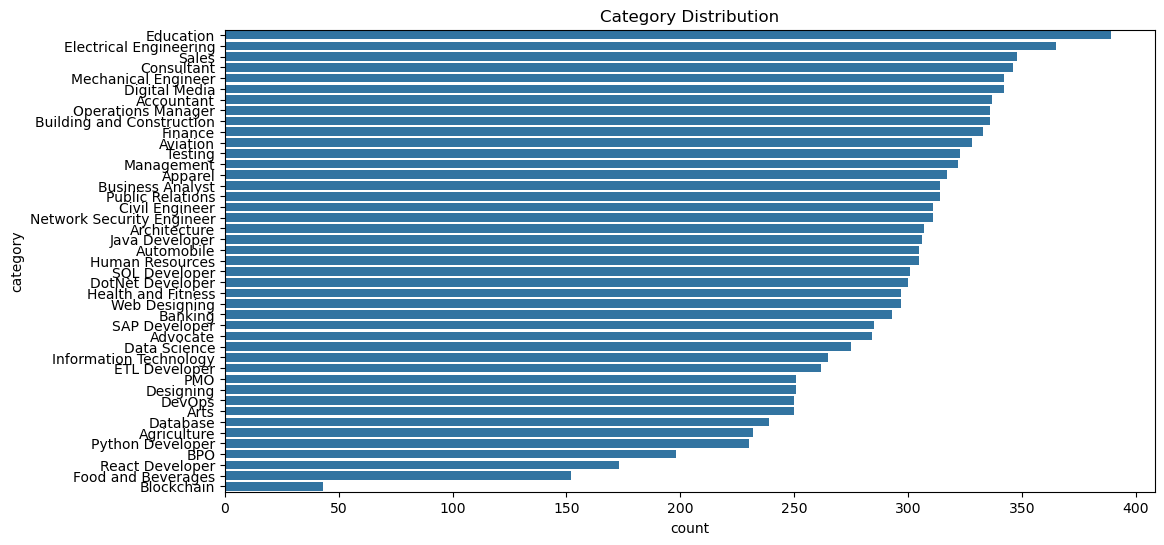

In [39]:
plt.figure(figsize=(12,6))
sns.countplot(y=data['category'], order=data['category'].value_counts().index)
plt.title("Category Distribution")
plt.show()

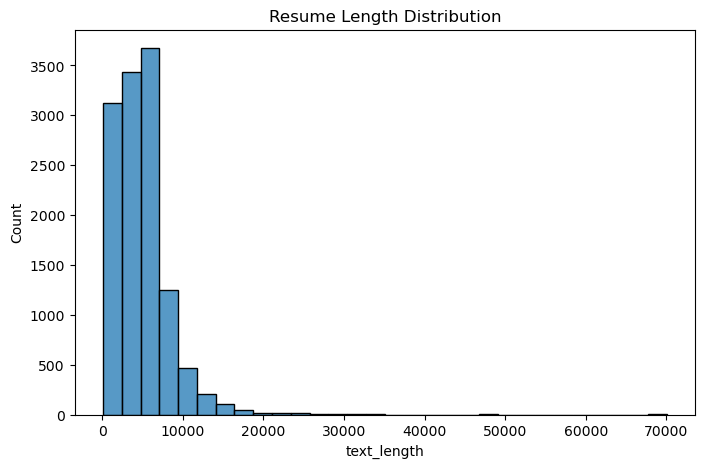

In [40]:
data['text_length'] = data['resume_text'].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(data['text_length'], bins=30)
plt.title("Resume Length Distribution")
plt.show()

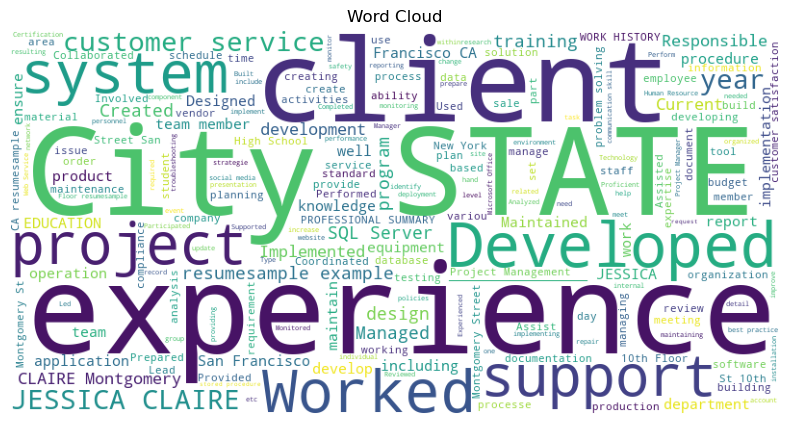

In [41]:
text = " ".join(data['resume_text'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.title("Word Cloud")
plt.show()

In [42]:
import re

def preprocess_text(text):
    text = str(text).lower()

    # Remove emails (full)
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove phone numbers
    text = re.sub(r'\+?\d[\d\s\-]{8,}\d', ' ', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove leftover email words like 'gmail com', 'yahoo com'
    text = re.sub(r'\b(gmail|yahoo|hotmail|outlook|com|mail)\b', ' ', text)

    # Remove common location words (extend if needed)
    locations = ['birmingham','chicago','london','new','york','india','delhi','mumbai']
    for loc in locations:
        text = text.replace(loc, ' ')

    # Remove special characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = text.split()

    # Remove short + stopwords + lemmatize
    from nltk.corpus import stopwords
    from nltk.stem import WordNetLemmatizer

    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    words = [
        lemmatizer.lemmatize(w)
        for w in words
        if w not in stop_words and len(w) > 2
    ]

    return " ".join(words)

In [43]:
data['cleaned_text'] = data['resume_text'].apply(preprocess_text)

In [44]:
print(data['cleaned_text'].iloc[0])

education omba executive leadership university texas bachelor science accounting richland college training certification certified management accountant cma certified financial modeling valuation analyst compliance anti money laundering american institute banking certified public account cpa lean six sigma green belt certified trade product financial regulation american institute banking achievement speaker bringing leader within successfully presented empowering speech leadership participant speaker dallas convention cpa successfully delivered seminar cpa convention guest teaching experience online teacher udemy taught online accounting non accountant course udemy similar online teaching platform developed effective teaching module material curriculum target student took feedback student assist improving teaching methodology material professional membership affiliation american society executive present technical skill quickbooks erp sap oracle hyperion language english native fellow 

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

X = data['cleaned_text']
y = data['category']

vectorizer = TfidfVectorizer(max_features=4000, ngram_range=(1,2))

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [47]:
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [ ]:
import streamlit as st
import pickle
import re
import nltk
import os
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from docx import Document
import PyPDF2

# ---------------- PAGE CONFIG ----------------
st.set_page_config(
    page_title="AI Resume Pro",
    page_icon="📄",
    layout="wide"
)

# ---------------- NLTK ----------------
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# ---------------- LOAD FILES ----------------
BASE_DIR = os.path.dirname(os.path.abspath(__file__))

model = pickle.load(open(os.path.join(BASE_DIR, "model.pkl"), "rb"))
vectorizer = pickle.load(open(os.path.join(BASE_DIR, "vectorizer.pkl"), "rb"))

# ---------------- SESSION STORAGE ----------------
if "resumes" not in st.session_state:
    st.session_state.resumes = []

# ---------------- CSS ----------------
st.markdown("""
<style>
.main-title {
    font-size: 42px;
    font-weight: bold;
    color: #0a66c2;
}
.card {
    background-color: #ffffff;
    padding: 20px;
    border-radius: 14px;
    box-shadow: 0px 4px 14px rgba(0,0,0,0.08);
    margin-bottom: 18px;
}
.stButton>button {
    background: linear-gradient(90deg,#0a66c2,#00a6ff);
    color: white;
    border-radius: 10px;
    height: 3em;
    width: 100%;
    font-size: 16px;
    border: none;
}
</style>
""", unsafe_allow_html=True)

# ---------------- PREPROCESS ----------------
def preprocess_text(text):
    text = str(text).lower()

    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'\+?\d[\d\s\-]{8,}\d', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()

    words = [
        lemmatizer.lemmatize(w)
        for w in words
        if w not in stop_words and len(w) > 2
    ]

    return " ".join(words)

# ---------------- FILE EXTRACTION ----------------
def extract_text_from_docx(file):
    doc = Document(file)
    return "\n".join([para.text for para in doc.paragraphs])

def extract_text_from_pdf(file):
    text = ""
    try:
        reader = PyPDF2.PdfReader(file)
        for page in reader.pages:
            page_text = page.extract_text()
            if page_text:
                text += page_text + " "
        return text.strip()
    except:
        return ""

# ---------------- SIDEBAR ----------------
st.sidebar.title("🚀 AI Resume Pro")
page = st.sidebar.radio(
    "Navigation",
    ["🏠 Home", "📁 Stored Resumes", "🎯 JD Matcher"]
)

# ======================================================
# HOME PAGE
# ======================================================
if page == "🏠 Home":

    st.markdown('<p class="main-title">📄 AI Resume Screening System</p>', unsafe_allow_html=True)
    st.write("Upload multiple resumes in PDF or DOCX format.")

    files = st.file_uploader(
        "Upload Resumes",
        type=["pdf", "docx"],
        accept_multiple_files=True
    )

    if files:
        for file in files:

            text = ""

            if file.name.endswith(".pdf"):
                text = extract_text_from_pdf(file)

            elif file.name.endswith(".docx"):
                text = extract_text_from_docx(file)

            if text:
                cleaned = preprocess_text(text)

                st.session_state.resumes.append({
                    "name": file.name,
                    "raw_text": text,
                    "cleaned_text": cleaned
                })

        st.success(f"{len(files)} resumes uploaded successfully!")

    st.markdown('<div class="card">', unsafe_allow_html=True)
    st.subheader("📊 Dashboard Stats")
    st.write("Stored Resumes:", len(st.session_state.resumes))
    st.markdown('</div>', unsafe_allow_html=True)

# ======================================================
# STORED RESUMES PAGE
# ======================================================
elif page == "📁 Stored Resumes":

    st.markdown('<p class="main-title">📁 Stored Resume Classifier</p>', unsafe_allow_html=True)

    if len(st.session_state.resumes) == 0:
        st.warning("No resumes uploaded yet.")

    else:
        selected = st.selectbox(
            "Select Resume",
            [r["name"] for r in st.session_state.resumes]
        )

        resume = next(r for r in st.session_state.resumes if r["name"] == selected)

        if st.button("🔍 Predict Category"):

            X = vectorizer.transform([resume["cleaned_text"]])

            prediction = model.predict(X)[0]

            st.markdown('<div class="card">', unsafe_allow_html=True)
            st.success(f"🎯 Predicted Category: {prediction}")
            st.markdown('</div>', unsafe_allow_html=True)

# ======================================================
# JD MATCHER PAGE
# ======================================================
elif page == "🎯 JD Matcher":

    st.markdown('<p class="main-title">🎯 Job Description Matcher</p>', unsafe_allow_html=True)

    jd_text = st.text_area("Paste Job Description", height=220)

    if st.button("🚀 Find Best Candidates"):

        if len(st.session_state.resumes) == 0:
            st.warning("Upload resumes first.")

        elif jd_text.strip() == "":
            st.warning("Paste job description.")

        else:
            cleaned_jd = preprocess_text(jd_text)

            jd_vec = vectorizer.transform([cleaned_jd])

            results = []

            for r in st.session_state.resumes:

                resume_vec = vectorizer.transform([r["cleaned_text"]])

                score = cosine_similarity(resume_vec, jd_vec)[0][0] * 100

                pred = model.predict(resume_vec)[0]

                results.append((r["name"], pred, score))

            results = sorted(results, key=lambda x: x[2], reverse=True)

            st.subheader("🏆 Top Matches")

            for name, pred, score in results[:5]:

                st.markdown('<div class="card">', unsafe_allow_html=True)

                st.write(f"📄 Resume: {name}")
                st.write(f"🎯 Predicted Role: {pred}")
                st.progress(min(int(score), 100))
                st.write(f"📊 Match Score: {round(score,2)}%")

                st.markdown('</div>', unsafe_allow_html=True)

# ---------------- FOOTER ----------------
st.markdown("---")
st.caption("Built using NLP + Machine Learning + Streamlit")


===== Logistic Regression =====
Accuracy: 0.7795148247978436
Classification Report:
                            precision    recall  f1-score   support

               Accountant       0.81      0.91      0.86       101
                 Advocate       0.70      0.86      0.77        85
              Agriculture       0.88      0.71      0.79        70
                  Apparel       0.69      0.87      0.77        95
             Architecture       0.88      0.72      0.79        92
                     Arts       0.81      0.72      0.76        75
               Automobile       0.67      0.67      0.67        92
                 Aviation       0.87      0.89      0.88        98
                      BPO       0.59      0.27      0.37        59
                  Banking       0.80      0.77      0.79        88
               Blockchain       1.00      0.85      0.92        13
Building and Construction       0.77      0.86      0.81       101
         Business Analyst       0.81      

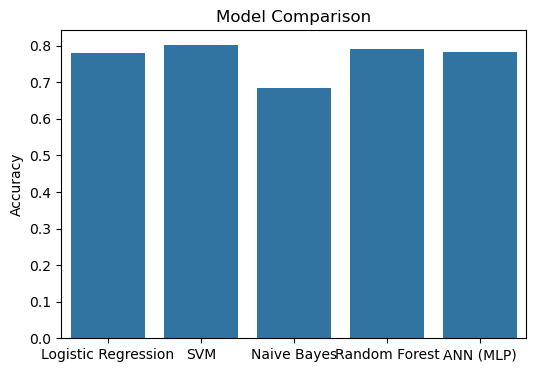

In [49]:
plt.figure(figsize=(6,4))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [50]:
best_model_name = max(results, key=results.get)
print("Best Model:", best_model_name)

best_model = models[best_model_name]

Best Model: SVM


In [51]:
def predict_category(text):
    text = preprocess_text(text)
    vec = vectorizer.transform([text])
    return best_model.predict(vec)[0]

sample = "Experience in python machine learning data analysis"
print("Predicted Role:", predict_category(sample))

Predicted Role: Python Developer


In [52]:
import pickle

pickle.dump(best_model, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))